# MNIST Digit Classifier

Feedforward network for classifying handwritten digits (0-9) from MNIST.

Data loading → model → training with MLflow tracking → evaluation on the held-out test set → error inspection.

Model, training loop, and eval helpers live in `model.py`, `train.py`, and `evaluate.py`. This notebook is the driver and lab notes for the experimentation.

## Setup

Imports plus device detection — training uses GPU/MPS when available, CPU otherwise.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Dataset Loading & Normalization

MNIST ships as raw pixel values in `[0, 255]`. Before picking normalization constants, it's worth checking the actual mean/std of the training set rather than assuming standard values.

In [3]:
# Check pixel statistics on raw (unnormalized) data before deciding on normalization constants
raw_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

pixels = raw_dataset.data.numpy().astype(np.float32) / 255
print(f"train shape: {pixels.shape}")  # 60,000 images, 28x28 each
print(f"mean = {pixels.mean():.4f}, std = {pixels.std():.4f}")

train shape: (60000, 28, 28)
mean = 0.1307, std = 0.3081


In [4]:
# Normalize using the dataset's own mean/std (computed above), the standard MNIST convention
custom_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=custom_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=custom_transform)

## Data Understanding

Sanity-check shapes, labels, and value ranges before building anything on top of the data.

train_dataset: torch.Size([60000, 28, 28])
test_dataset:  torch.Size([10000, 28, 28])

sample image shape: torch.Size([1, 28, 28])
sample label: 5
pixel range after normalization: (-0.4242, 2.8215)


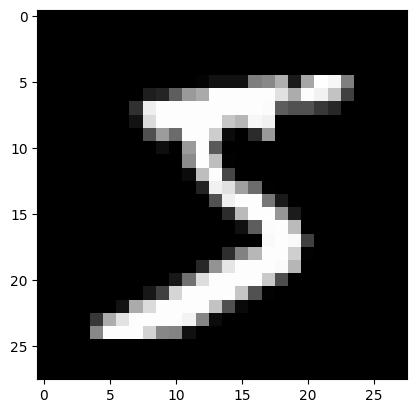

In [5]:
print(f"train_dataset: {train_dataset.data.shape}")
print(f"test_dataset:  {test_dataset.data.shape}")

# spot-check a single sample end to end
img, label = train_dataset[0]
print(f"\nsample image shape: {img.shape}")
print(f"sample label: {label}")
print(f"pixel range after normalization: ({img.min():.4f}, {img.max():.4f})")

plt.imshow(train_dataset.data[0], cmap='gray')

## DataLoaders

Batch the datasets for training. Train is shuffled to break up any ordering bias; test stays in order since shuffling doesn't matter for evaluation.

In [6]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False, num_workers=2)

# confirm batch shapes look right before writing the training loop
batch_iter = iter(train_loader)
images, labels = next(batch_iter)
print(f"batch: images = {images.shape}, labels = {labels.shape}")

batch: images = torch.Size([64, 1, 28, 28]), labels = torch.Size([64])


## Model Architecture

Going with a simple 3-layer fully connected network, narrowing the width at each step: 784 in → 256 → 128 → 10 out (one per digit class).

```
Input: 784 (28x28 flattened)
  -> Linear(784, 256) -> ReLU
  -> Linear(256, 128) -> ReLU
  -> Linear(128, 10)   <- raw logits, no softmax here
Output: 10 class logits
```

ReLU sits between the hidden layers only, not after the final `Linear`. `CrossEntropyLoss` expects raw logits and applies softmax internally — adding softmax here too would double up and destabilize the loss.

Expected param count: `(784×256 + 256) + (256×128 + 128) + (128×10 + 10) = 235,146`

Model is defined in `model.py` (`DigitClassifier`) rather than inline, so it can be reused by `train.py` for standalone runs outside the notebook.

In [7]:
from model import DigitClassifier

model = DigitClassifier().to(device)

In [8]:
# Verify actual param count matches the manual calculation above
expected_params = (784 * 256 + 256) + (256 * 128 + 128) + (128 * 10 + 10)
actual_params = sum(p.numel() for p in model.parameters())

print(f"expected: {expected_params}")
print(f"actual:   {actual_params}")
assert expected_params == actual_params

expected: 235146
actual:   235146


## Training

Cross-entropy loss with Adam. MLflow tracks hyperparameters and per-epoch metrics so runs are comparable later without digging through print output.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
import mlflow
import mlflow.pytorch
from evaluate import evaluate

NUM_EPOCHS = 10
train_losses = []
val_accuracies = []

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("mnist-classifier")

with mlflow.start_run(run_name="3layer_feedforward"):
    mlflow.log_params({
        "architecture": "784-256-128-10",
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": NUM_EPOCHS,
        "activation": "ReLU",
        "loss": "CrossEntropyLoss"
    })

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        val_acc = evaluate(model, test_loader, device)

        train_losses.append(avg_loss)
        val_accuracies.append(val_acc)

        mlflow.log_metric("train_loss", avg_loss, step=epoch)
        mlflow.log_metric("val_accuracy", val_acc, step=epoch)

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS:02d} | train_loss = {avg_loss:.4f} | val_acc = {val_acc:.4f}")

    mlflow.pytorch.log_model(model, "model")

Epoch 01/10 | train_loss = 0.2274 | val_acc = 0.9684
Epoch 02/10 | train_loss = 0.0935 | val_acc = 0.9727
Epoch 03/10 | train_loss = 0.0649 | val_acc = 0.9778
Epoch 04/10 | train_loss = 0.0498 | val_acc = 0.9743
Epoch 05/10 | train_loss = 0.0396 | val_acc = 0.9780
Epoch 06/10 | train_loss = 0.0324 | val_acc = 0.9778
Epoch 07/10 | train_loss = 0.0274 | val_acc = 0.9767
Epoch 08/10 | train_loss = 0.0253 | val_acc = 0.9799
Epoch 09/10 | train_loss = 0.0224 | val_acc = 0.9765


2026/07/12 22:18:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 22:18:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 10/10 | train_loss = 0.0205 | val_acc = 0.9780


## Evaluation

Final accuracy on the held-out test set, followed by a per-class breakdown and confusion matrix to see where the model is actually making mistakes.

In [11]:
test_accuracy = evaluate(model, test_loader, device)
print(f"Final test accuracy: {test_accuracy*100:.2f}%")

Final test accuracy: 97.80%


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.96      0.99      0.97       982
           5       0.97      0.98      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



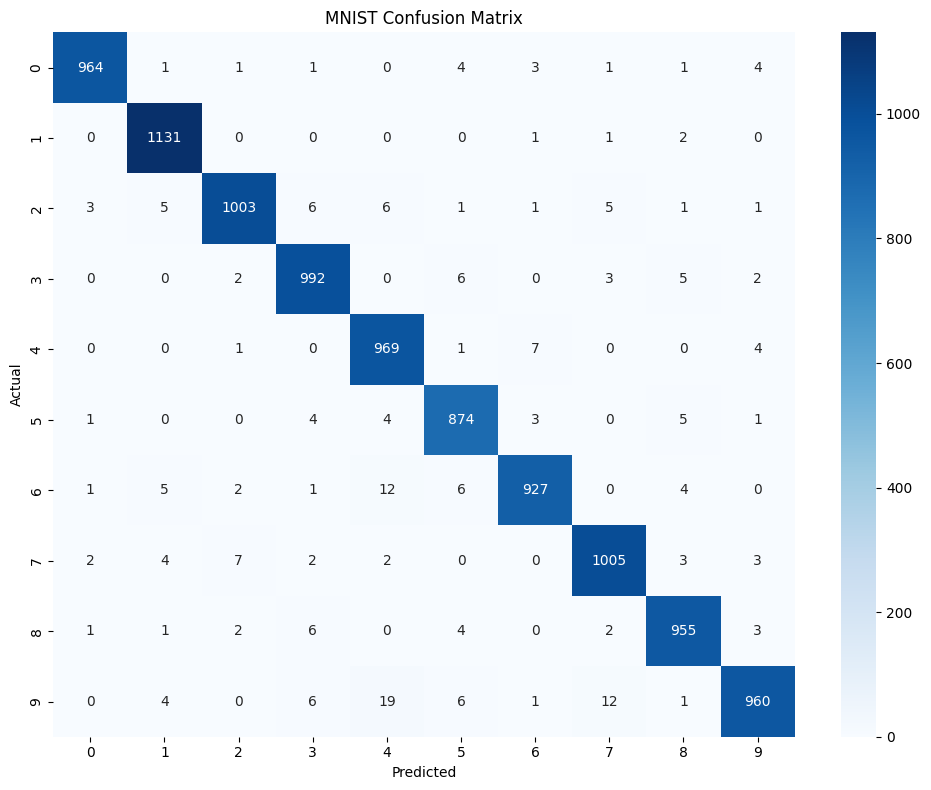

In [12]:
# Per-digit precision/recall/F1 plus confusion matrix (saved to reports/figures/)
from evaluate import full_evaluation

full_evaluation(model, test_loader, device)

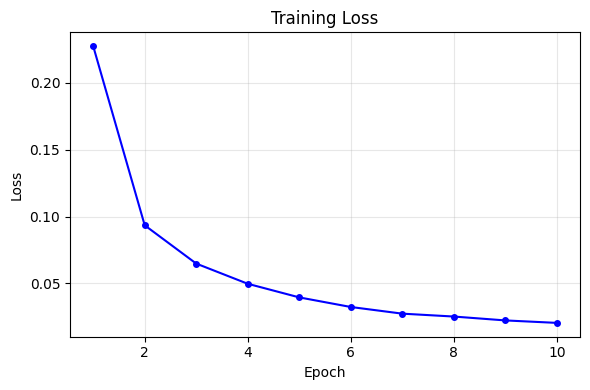

Saved to reports/figures/loss_curve.png


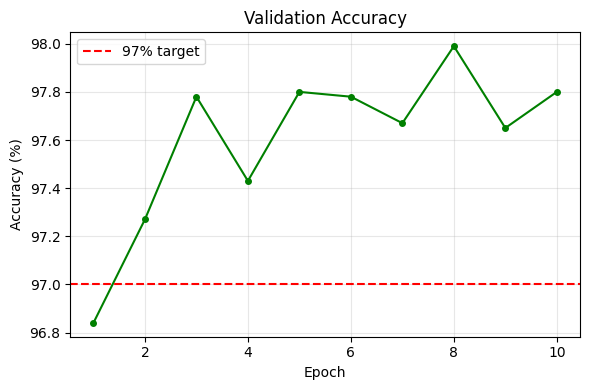

Saved to reports/figures/accuracy_curve.png


In [13]:
# Loss and accuracy curves across epochs (saved to reports/figures/)
from evaluate import plot_training_curves

plot_training_curves(train_losses, val_accuracies)

## Log Artifacts to MLflow

Attach the test accuracy and evaluation plots to the same run that produced them, so everything for a given experiment lives in one place.

In [14]:
last_run_id = mlflow.last_active_run().info.run_id
mlflow.end_run()  # clear any stale active run left over from an earlier interrupted start_run()

with mlflow.start_run(run_id=last_run_id):
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_artifact("reports/figures/loss_curve.png")
    mlflow.log_artifact("reports/figures/accuracy_curve.png")
    mlflow.log_artifact("reports/figures/confusion_matrix.png")

print(f"Logged to run {last_run_id}")

Logged to run 225d205fead94454aa68c12a80a3120c


## Conclusion

The 3-layer feedforward network lands around 97.8% test accuracy after 10 epochs — a solid baseline for MNIST, though well short of what a CNN would get (typically 99%+).

Where I'd take this if I kept going:
- Swap in a small CNN (conv + pooling) to capture spatial structure instead of flattening pixels
- Add dropout or weight decay if a deeper network starts overfitting
- Sweep learning rate and hidden layer sizes as separate MLflow runs for a proper comparison
- Dig into the confusion matrix's biggest off-diagonal cells — 9 shows up as the most common wrong guess for several digits, worth a closer look at which samples it's missing